# 05 — CNN Training for LULC Classification
Patch-based CNN on Landsat bands + NDVI to predict LULC classes.

**Requires:** Run notebooks 01–03 first (`features_labels.npz`).

In [1]:
import json, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split
from itertools import product

In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
with open(os.path.join(PROJECT_ROOT, 'data', 'config.json')) as f:
    cfg = json.load(f)
FIG_DIR = cfg['paths']['fig_dir']
MODEL_DIR = cfg['paths']['model_dir']
PROCESSED_DIR = cfg['paths']['processed_dir']
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

data = np.load(os.path.join(PROCESSED_DIR, 'features_labels.npz'))
features = data['features'].astype('float32')  # (5, H, W)
labels_raw = data['labels']                      # (H, W)

LULC_CLASSES = {
    1: ('Water', '#1A5BAB'), 2: ('Trees', '#358221'), 4: ('Flooded Vegetation', '#87D19E'),
    5: ('Crops', '#FFDB5C'), 7: ('Built Area', '#ED022A'), 8: ('Bare Ground', '#EDE9E4'),
    9: ('Snow/Ice', '#F2FAFF'), 10: ('Clouds', '#C8C8C8'), 11: ('Rangeland', '#C6AD8D'),
}

# Encode labels to sequential 0..N-1
valid_mask = labels_raw > 0
valid_classes = sorted(np.unique(labels_raw[valid_mask]))
class_to_idx = {int(c): i for i, c in enumerate(valid_classes)}
idx_to_class = {i: int(c) for c, i in class_to_idx.items()}
num_classes = len(valid_classes)
class_names = [LULC_CLASSES[idx_to_class[i]][0] for i in range(num_classes)]

labels_enc = np.full(labels_raw.shape, -1, dtype=np.int64)
for c, i in class_to_idx.items():
    labels_enc[labels_raw == c] = i

print(f'Features: {features.shape} | Classes: {num_classes} → {class_names}')

Features: (5, 239, 253) | Classes: 6 → ['Water', 'Trees', 'Flooded Vegetation', 'Crops', 'Built Area', 'Rangeland']


## 5.1 Patch-Based Dataset

In [3]:
PATCH_SIZE = 7

class LULCPatchDataset(Dataset):
    def __init__(self, features, labels, patch_size=7):
        self.features = features
        self.labels = labels
        self.half = patch_size // 2
        H, W = labels.shape
        rows, cols = np.where(
            (labels >= 0) &
            (np.arange(H)[:, None] >= self.half) &
            (np.arange(H)[:, None] < H - self.half) &
            (np.arange(W)[None, :] >= self.half) &
            (np.arange(W)[None, :] < W - self.half)
        )
        self.coords = list(zip(rows, cols))
        print(f'Valid patches: {len(self.coords)}')

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        r, c = self.coords[idx]
        h = self.half
        patch = self.features[:, r-h:r+h+1, c-h:c+h+1]
        label = self.labels[r, c]
        return torch.FloatTensor(patch), torch.tensor(label, dtype=torch.long)

dataset = LULCPatchDataset(features, labels_enc, PATCH_SIZE)

Valid patches: 57551


## 5.2 Train / Validation / Test Split (60/20/20)

In [4]:
all_idx = list(range(len(dataset)))
all_lab = [dataset.labels[r, c] for r, c in dataset.coords]

train_idx, temp_idx, _, temp_lab = train_test_split(
    all_idx, all_lab, test_size=0.4, random_state=42, stratify=all_lab)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_lab, test_size=0.5, random_state=42, stratify=temp_lab)

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

BS = 256
train_loader = DataLoader(Subset(dataset, train_idx), batch_size=BS, shuffle=True, num_workers=0)
val_loader   = DataLoader(Subset(dataset, val_idx),   batch_size=BS, shuffle=False, num_workers=0)
test_loader  = DataLoader(Subset(dataset, test_idx),  batch_size=BS, shuffle=False, num_workers=0)

Train: 34530 | Val: 11510 | Test: 11511


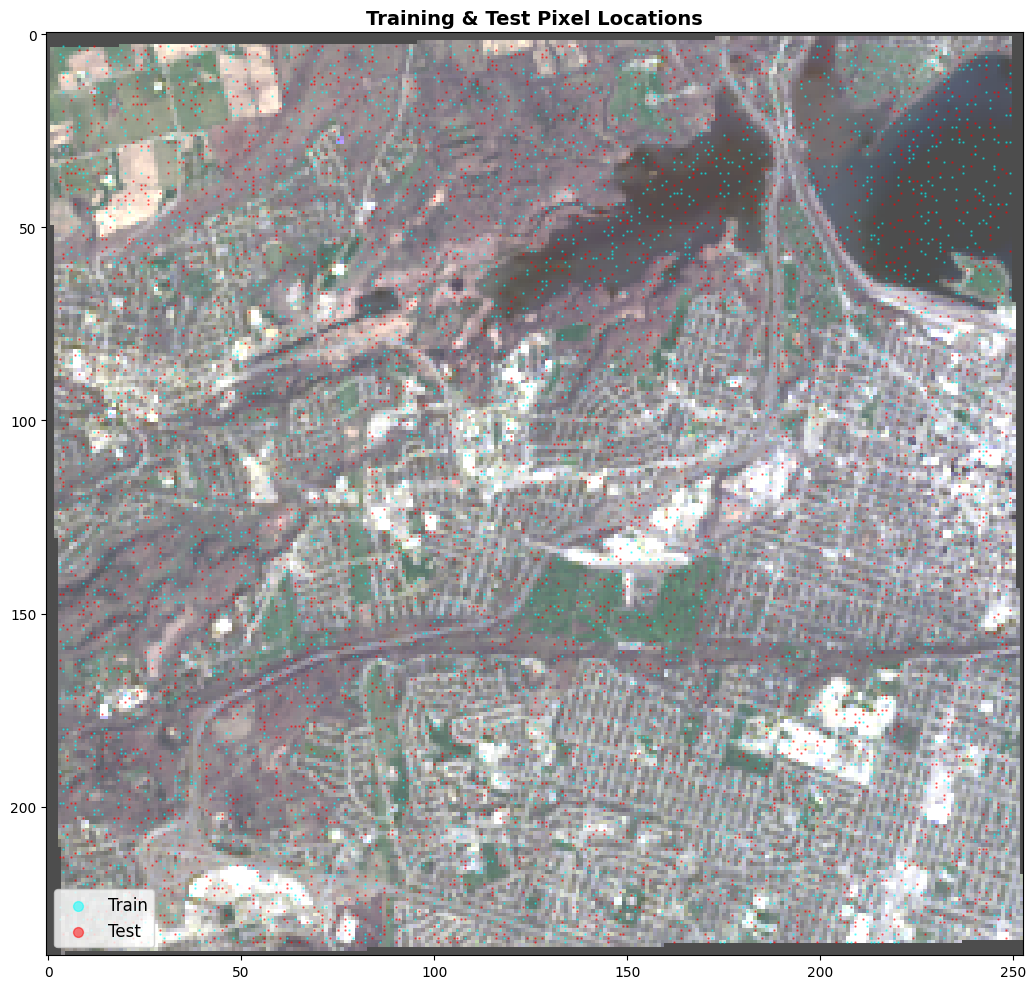

Saved: /content/lulc_notebook_project/outputs/figures/05_train_test_overlay.png


In [5]:
# Visualize train/test pixels overlaid on True Color composite
def pnorm(x):
    v = x[x > 0]
    if len(v) == 0: return x
    lo, hi = np.percentile(v, [2, 98])
    return np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)

rgb = np.dstack([pnorm(features[2]), pnorm(features[1]), pnorm(features[0])])

fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(rgb, alpha=0.7)

np.random.seed(42)
sub = 5000
tc = np.array([dataset.coords[i] for i in train_idx])
tec = np.array([dataset.coords[i] for i in test_idx])
if len(tc) > sub: tc = tc[np.random.choice(len(tc), sub, replace=False)]
if len(tec) > sub: tec = tec[np.random.choice(len(tec), sub, replace=False)]

ax.scatter(tc[:, 1], tc[:, 0], c='cyan', s=0.5, alpha=0.5, label='Train')
ax.scatter(tec[:, 1], tec[:, 0], c='red', s=0.5, alpha=0.5, label='Test')
ax.legend(fontsize=12, markerscale=10)
ax.set_title('Training & Test Pixel Locations', fontsize=14, fontweight='bold')
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '05_train_test_overlay.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 5.3 CNN Architecture

In [6]:
class LULC_CNN(nn.Module):
    def __init__(self, in_ch=5, n_cls=7, ps=7):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
        )
        dummy = torch.zeros(1, in_ch, ps, ps)
        flat = self.feat(dummy).view(1, -1).size(1)
        self.clf = nn.Sequential(
            nn.Dropout(0.4), nn.Linear(flat, 256), nn.ReLU(True),
            nn.Dropout(0.3), nn.Linear(256, 64), nn.ReLU(True),
            nn.Linear(64, n_cls),
        )
    def forward(self, x):
        x = self.feat(x)
        return self.clf(x.view(x.size(0), -1))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
model = LULC_CNN(5, num_classes, PATCH_SIZE).to(device)
print(model)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Device: cuda


LULC_CNN(
  (feat): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
  )
  (clf): Sequential(
    (0): Dropout(p=0.4, inplace=False)
    (1): Linear(in_features=1152, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_featu

## 5.4 Hyperparameter Tuning on Validation Set

In [7]:
def quick_train_eval(lr, wd, epochs=10):
    m = LULC_CNN(5, num_classes, PATCH_SIZE).to(device)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    crit = nn.CrossEntropyLoss()
    sch = optim.lr_scheduler.StepLR(opt, 5, 0.5)
    for _ in range(epochs):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(m(xb), yb); loss.backward(); opt.step()
        sch.step()
    m.eval(); correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = m(xb).argmax(1)
            total += yb.size(0); correct += (pred == yb).sum().item()
    return correct / total, m.state_dict()

lrs = [1e-3, 5e-4, 1e-4]
wds = [1e-4, 1e-5]
best_acc, best_hp, best_state = 0, {}, None

print('Hyperparameter Tuning:')
print('-' * 45)
results_hp = []
for lr, wd in product(lrs, wds):
    acc, state = quick_train_eval(lr, wd)
    results_hp.append((lr, wd, acc))
    print(f'  LR={lr:.0e}  WD={wd:.0e}  → Val Acc: {acc:.4f}')
    if acc > best_acc:
        best_acc, best_hp, best_state = acc, {'lr': lr, 'wd': wd}, state

print(f'\nBest: {best_hp} → {best_acc:.4f}')

Hyperparameter Tuning:
---------------------------------------------


  LR=1e-03  WD=1e-04  → Val Acc: 0.9343


  LR=1e-03  WD=1e-05  → Val Acc: 0.9414


  LR=5e-04  WD=1e-04  → Val Acc: 0.9360


  LR=5e-04  WD=1e-05  → Val Acc: 0.9359


  LR=1e-04  WD=1e-04  → Val Acc: 0.9186


  LR=1e-04  WD=1e-05  → Val Acc: 0.9149

Best: {'lr': 0.001, 'wd': 1e-05} → 0.9414


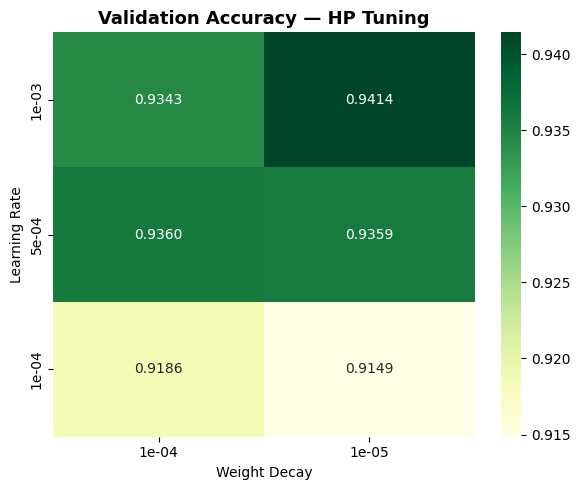

Saved: /content/lulc_notebook_project/outputs/figures/05_hp_tuning_heatmap.png


In [8]:
# Hyperparameter tuning heatmap
acc_grid = np.array([r[2] for r in results_hp]).reshape(len(lrs), len(wds))
fig, ax = plt.subplots(figsize=(6, 5))
import seaborn as sns
sns.heatmap(acc_grid, annot=True, fmt='.4f', cmap='YlGn',
            xticklabels=[f'{w:.0e}' for w in wds],
            yticklabels=[f'{l:.0e}' for l in lrs], ax=ax)
ax.set_xlabel('Weight Decay'); ax.set_ylabel('Learning Rate')
ax.set_title('Validation Accuracy — HP Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '05_hp_tuning_heatmap.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 5.5 Final Training (30 Epochs)

In [9]:
NUM_EPOCHS = 30
model = LULC_CNN(5, num_classes, PATCH_SIZE).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=best_hp['lr'], weight_decay=best_hp['wd'])
scheduler = optim.lr_scheduler.StepLR(optimizer, 10, 0.5)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    rl = rc = rt = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb); loss = criterion(out, yb)
        loss.backward(); optimizer.step()
        rl += loss.item()*xb.size(0)
        rc += (out.argmax(1)==yb).sum().item(); rt += yb.size(0)
    train_losses.append(rl/rt); train_accs.append(rc/rt)

    model.eval()
    rl = rc = rt = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb); loss = criterion(out, yb)
            rl += loss.item()*xb.size(0)
            rc += (out.argmax(1)==yb).sum().item(); rt += yb.size(0)
    val_losses.append(rl/rt); val_accs.append(rc/rt)
    scheduler.step()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1:2d}/{NUM_EPOCHS}  '
              f'TrLoss={train_losses[-1]:.4f}  TrAcc={train_accs[-1]:.4f}  '
              f'VaLoss={val_losses[-1]:.4f}  VaAcc={val_accs[-1]:.4f}')

# Save model
ckpt_path = os.path.join(MODEL_DIR, 'lulc_cnn_best.pth')
torch.save({
    'model_state': model.state_dict(),
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class,
    'num_classes': num_classes,
    'patch_size': PATCH_SIZE,
    'best_hp': best_hp,
}, ckpt_path)
print(f'Model saved: {ckpt_path}')

Epoch  5/30  TrLoss=0.2073  TrAcc=0.9228  VaLoss=0.2431  VaAcc=0.9115


Epoch 10/30  TrLoss=0.1436  TrAcc=0.9456  VaLoss=0.1867  VaAcc=0.9343


Epoch 15/30  TrLoss=0.0841  TrAcc=0.9671  VaLoss=0.1642  VaAcc=0.9454


Epoch 20/30  TrLoss=0.0598  TrAcc=0.9766  VaLoss=0.1643  VaAcc=0.9513


Epoch 25/30  TrLoss=0.0337  TrAcc=0.9874  VaLoss=0.1657  VaAcc=0.9557


Epoch 30/30  TrLoss=0.0259  TrAcc=0.9906  VaLoss=0.2135  VaAcc=0.9489
Model saved: /content/lulc_notebook_project/outputs/models/lulc_cnn_best.pth


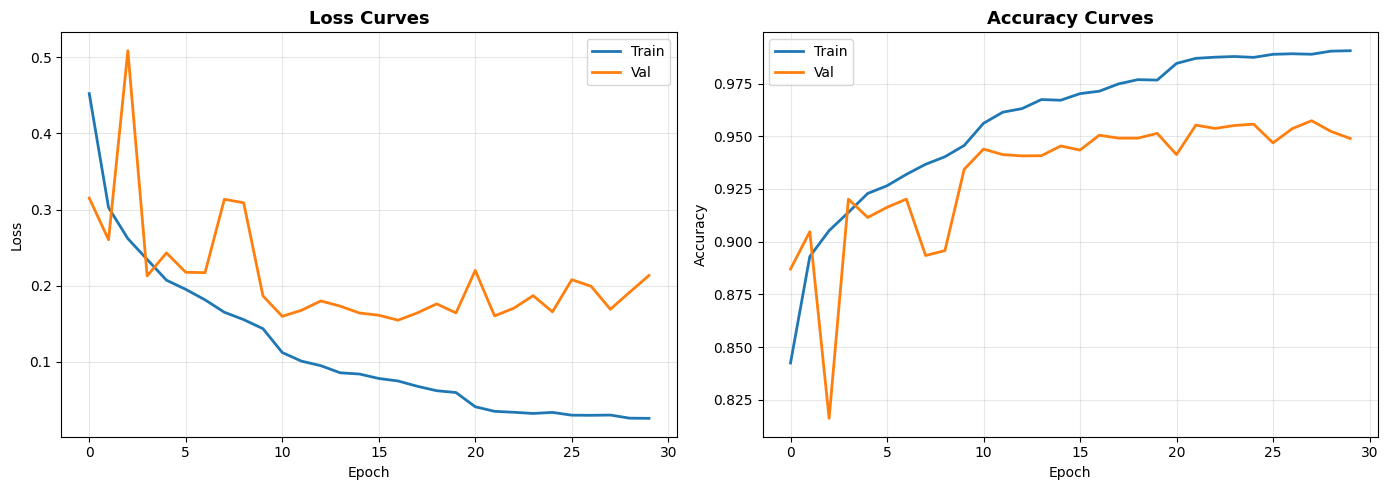

Saved: /content/lulc_notebook_project/outputs/figures/05_training_curves.png


In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(train_losses, label='Train', lw=2); axes[0].plot(val_losses, label='Val', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curves', fontsize=13, fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label='Train', lw=2); axes[1].plot(val_accs, label='Val', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, '05_training_curves.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
plt.show()
print('Saved:', fig_path)

## 5.6 Save Test Predictions for Notebook 06

In [11]:
model.eval()
all_preds, all_labels_t, all_probs = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        out = model(xb)
        probs = torch.softmax(out, dim=1)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels_t.extend(yb.numpy())
        all_probs.extend(probs.cpu().numpy())

np.savez_compressed(
    os.path.join(PROCESSED_DIR, 'test_predictions.npz'),
    preds=np.array(all_preds),
    labels=np.array(all_labels_t),
    probs=np.array(all_probs),
    class_names=class_names,
    idx_to_class=json.dumps(idx_to_class),
)
print('Saved test predictions for notebook 06.')

# Also save full-image predictions for the map
predicted_map = np.full(labels_enc.shape, -1, dtype=np.int64)
half = PATCH_SIZE // 2
H, W = features.shape[1], features.shape[2]
model.eval()
with torch.no_grad():
    for r in range(half, H - half):
        patches = []
        for c in range(half, W - half):
            patches.append(features[:, r-half:r+half+1, c-half:c+half+1])
        if patches:
            batch = torch.FloatTensor(np.array(patches)).to(device)
            preds = model(batch).argmax(1).cpu().numpy()
            for ci, c in enumerate(range(half, W - half)):
                predicted_map[r, c] = preds[ci]

# Map back to original class values
predicted_lulc = np.zeros_like(predicted_map, dtype=np.int16)
for idx, cls in idx_to_class.items():
    predicted_lulc[predicted_map == idx] = cls

np.savez_compressed(
    os.path.join(PROCESSED_DIR, 'predicted_lulc_map.npz'),
    predicted_lulc=predicted_lulc,
)
print('Saved predicted LULC map for notebook 06.')

Saved test predictions for notebook 06.


Saved predicted LULC map for notebook 06.
